In [1]:
import jax.numpy as jnp 
import jax
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import diffrax
import equinox

In [2]:
%matplotlib widget

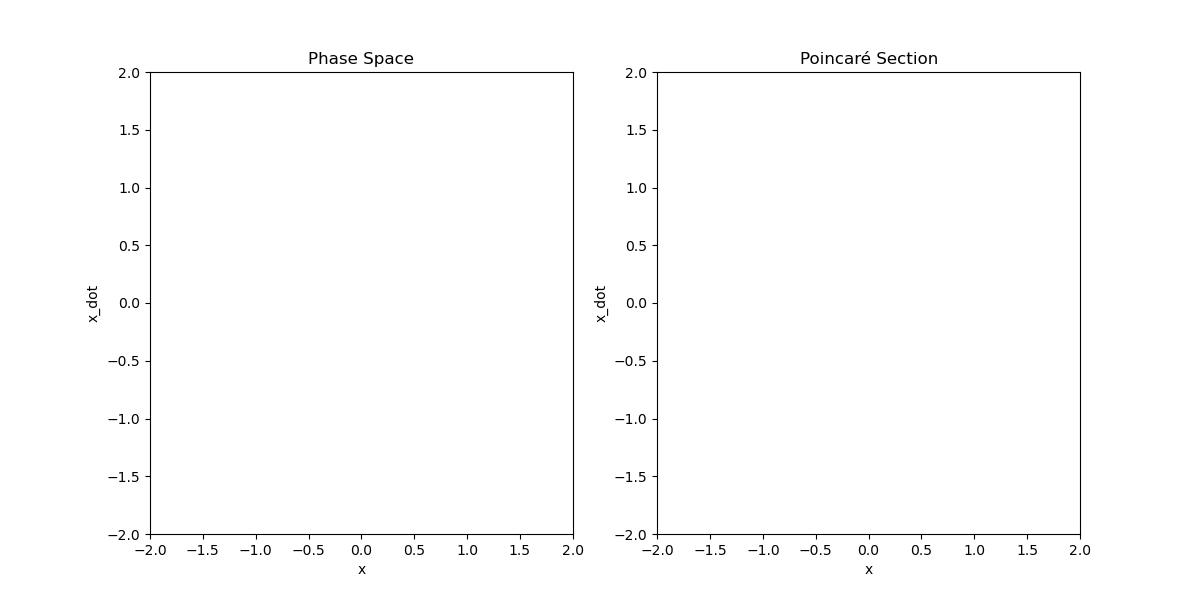

In [3]:
# Constants
C = 0.0
k = 0.53
omega = 1.2
gamma = 1.0
alpha = 1.0
beta = -1.0

#pointcare time interval
T = 2 * jnp.pi /(omega)


numFrames = 1

#variable to sweep across, should match name from constants
varToTest = "C"
values = jnp.linspace(0.1, .1, numFrames)



def dx_dt(t, x, params):
    #Basic Duffing ODE, added a term 'C' to show constant slope.
    C = params["C"]
    k = params["k"]
    omega = params["omega"]
    gamma = params["gamma"]
    alpha = params["alpha"]
    beta = params["beta"]

    return jnp.array([
        x[1],
        -beta*x[0]
        - k*x[1]
        - alpha*x[0]**3
        + gamma*jnp.cos(omega*t)
        + C
    ])

#Get our ODE solver setup
term = diffrax.ODETerm(dx_dt)
solver = diffrax.Tsit5()
y0 = jnp.array([0.0, 1.0])
ts = jnp.linspace(4000, 5000, 10000)

def solve_single(value):
    #Solde the ODE for one snapshot of constants
    params = {"C":C,"k":k,"omega":omega,"gamma":gamma,"alpha":alpha,"beta":beta}
    params[varToTest] = value  

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=5000,
        dt0=0.05,
        y0=y0,
        args=params,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=1_000_000,
    )
    return sol.ys

#call all the jax stuff up to now
batched_solve = jax.vmap(solve_single)
solutions = batched_solve(values)[:,1000:,] #throw away first 1000 points to focus on steady state operation

#matplotlib junk
fig, (ax_phase, ax_poincare) = plt.subplots(1, 2, figsize=(12,6))
phase_line, = ax_phase.plot([], [], lw=0.5)
poincare_scatter = ax_poincare.scatter(
    [], [],
    s=2,           
    c="red",       
    marker=".",    
)

ax_phase.set_title("Phase Space")
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("x_dot")
ax_poincare.set_title("Poincaré Section")
ax_poincare.set_xlabel("x")
ax_poincare.set_ylabel("x_dot")
ax_phase.set_xlim(-2,2)
ax_phase.set_ylim(-2,2)
ax_poincare.set_xlim(-2,2)
ax_poincare.set_ylim(-2,2)
param_text = ax_phase.text( #Set up persistant text on top of plot we can iterate with the constan's value
    0.02, 0.95, "",
    transform=ax_phase.transAxes,
    verticalalignment="top"
)

ts_array = ts[1000:]
poincare_times = jnp.arange(ts_array[0], ts_array[-1], T) + 25
poincare_indices = jnp.searchsorted(ts_array, poincare_times)


def update(frame):
    #Function required for animation, just goes through and crunches all the numbers for one frame of the animation
    current_value = values[frame]
    trajectory = solutions[frame]

    phase_line.set_data(
        trajectory[:,0],
        trajectory[:,1]
    )

    points.append()

    poincare = trajectory[poincare_indices][100:]

    poincare_scatter.set_offsets(
        jnp.column_stack((poincare[:,0], poincare[:,1]))
    )

    param_text.set_text(
        f"{varToTest} = {float(current_value):.4f}"
    )

    return phase_line, poincare_scatter, param_text

ani = animation.FuncAnimation(
    #Create a matplotlib animation
    fig, update, frames=numFrames, interval=50
)

#ani.save("duffing_animationVarC9t9N.mp4", writer="ffmpeg", fps=10)

In [ ]:
fig = plt.figure()
plt.plot(values)
plt.show()

Array([0.1], dtype=float32)

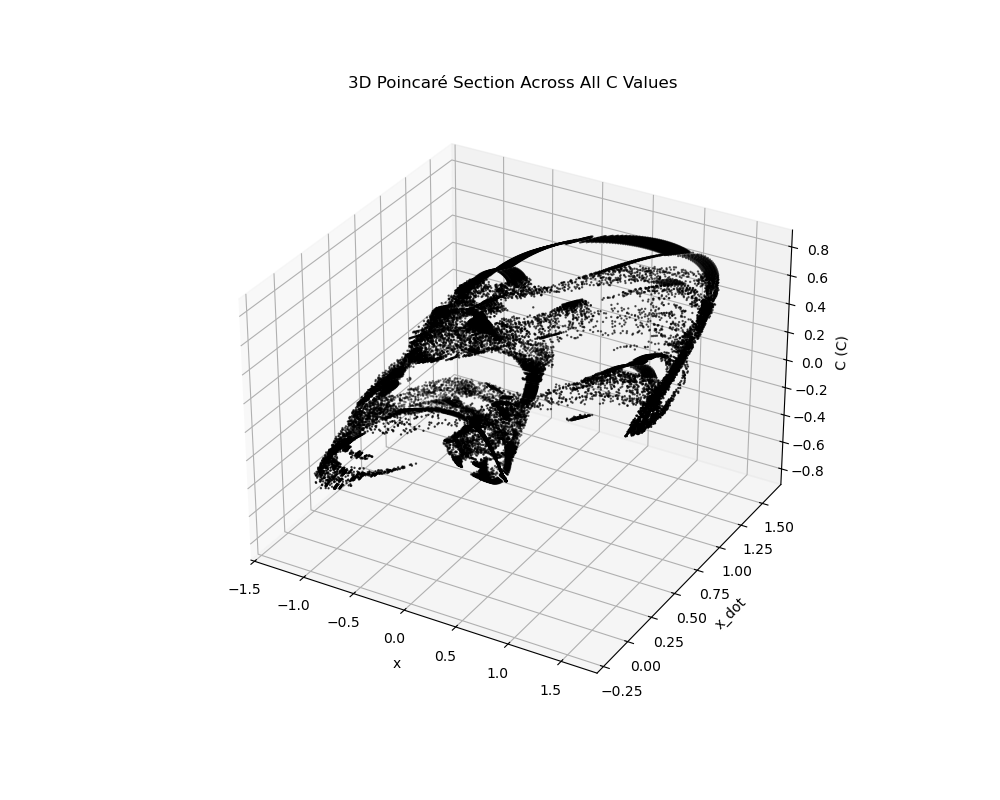

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    
    # Add the C value as the third dimension
    poincare_data.append(np.column_stack((poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))))

poincare_data = np.vstack(poincare_data)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(poincare_data[:, 0], poincare_data[:, 1], poincare_data[:, 2], s=2, c='black', marker='.')

ax.set_xlabel('x')
ax.set_ylabel('x_dot')
ax.set_zlabel(f'{varToTest} (C)')

ax.set_title("3D Poincaré Section Across All C Values")

plt.show()

/tmp/ipykernel_162368/1294098932.py:32: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


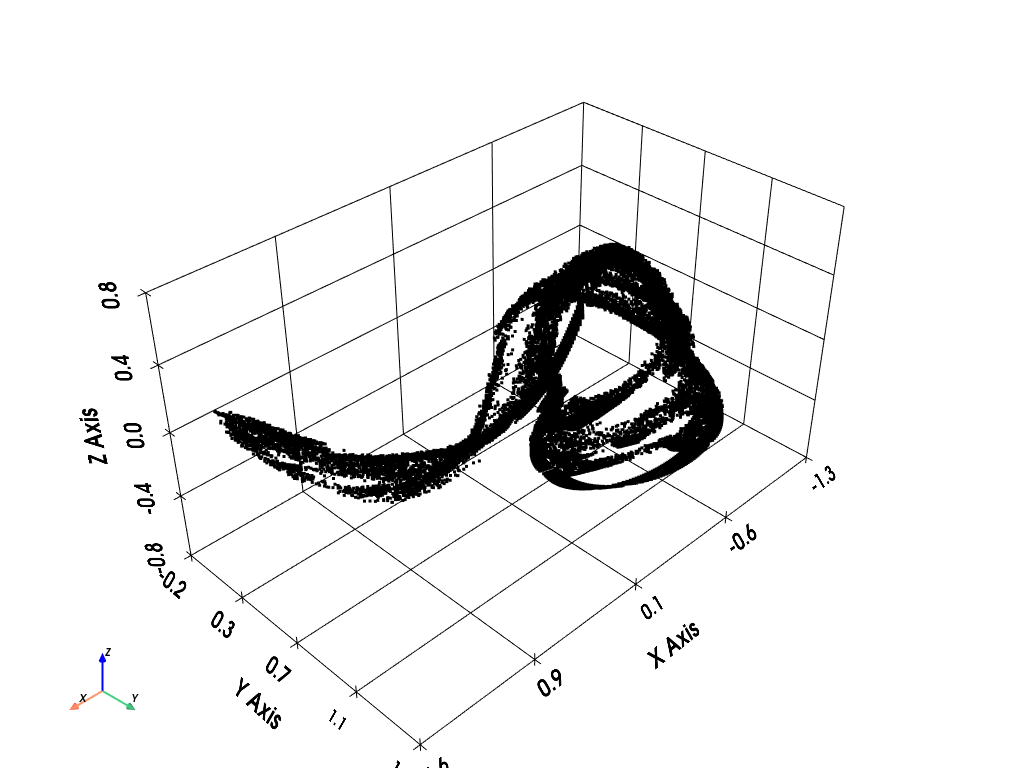

In [10]:
import numpy as np
import pyvista as pv

# Stack your data (same as before)
poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

points = np.vstack(poincare_data)

# Create PyVista point cloud
cloud = pv.PolyData(points)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="black",
    point_size=3,
    render_points_as_spheres=False
)

plotter.add_axes()
plotter.show_grid()

plotter.show()

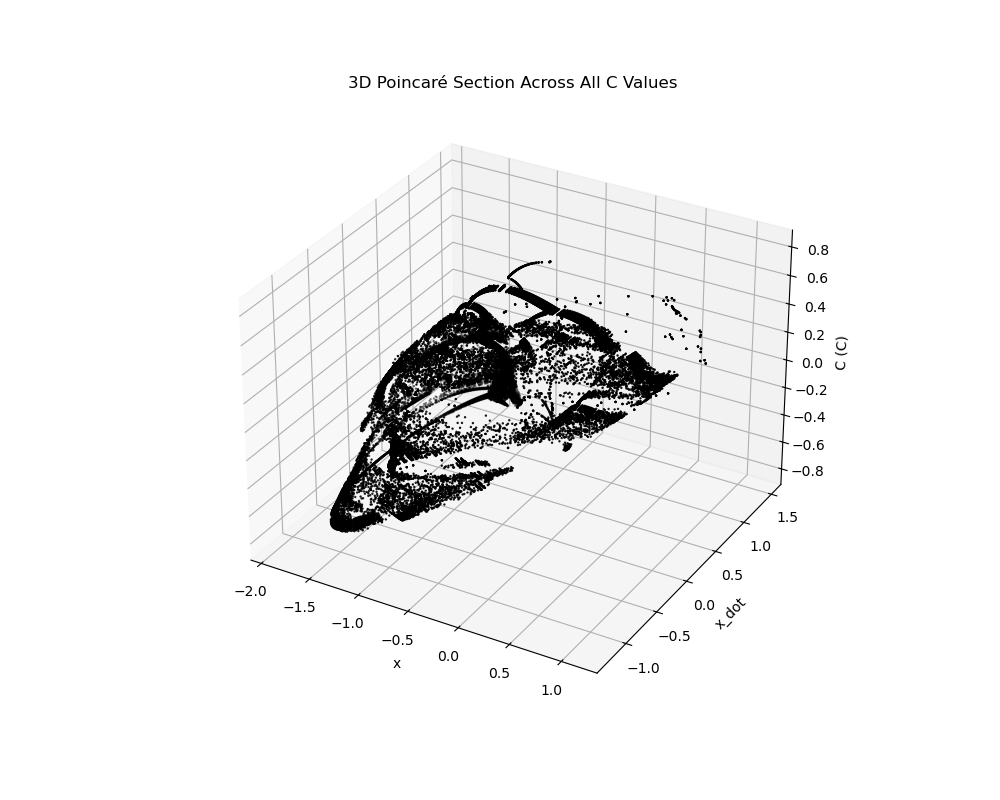

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

poincare_data = np.vstack(poincare_data)

# Create figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(
    poincare_data[:, 0],
    poincare_data[:, 1],
    poincare_data[:, 2],
    s=2,
    c='black',
    marker='.'
)

ax.set_xlabel('x')
ax.set_ylabel('x_dot')
ax.set_zlabel(f'{varToTest} (C)')
ax.set_title("3D Poincaré Section Across All C Values")

# Set fixed elevation
elevation = 20

def update(frame):
    ax.view_init(elev=frame, azim=90)
    return ax,

# Animate 360 degrees
ani = FuncAnimation(
    fig,
    update,
    frames=np.linspace(0, 360, 180),  # 180 frames for smooth rotation
    interval=50
)

plt.show()
ani.save("poincare_rotationZN.mp4", writer='ffmpeg', fps=30)